In [70]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import uniform_filter

with open('../../ETL/data/pickles/processed.pkl', 'rb') as file:
	data = pickle.load(file)

In [71]:
def lee_filter(img, size=7, noise_var=None):
    """
    img : float32 entre 0 et 1
    size : taille du voisinage (3,5,7…)
    """
    # moyenne locale
    mean = uniform_filter(img, size)
    # variance locale
    mean_sq = uniform_filter(img**2, size)
    var = mean_sq - mean**2

    # variance du bruit (supposée)
    noise_var = np.mean(var) if noise_var is None else noise_var
    print("Estimated noise variance =", noise_var)
    # poids
    w = var / (var + noise_var)
    
    # estimation Lee
    img_filtered = mean + w * (img - mean)

    return img_filtered


In [72]:
def estimate_speckle_var_from_patches(
    images,
    patch_size=16,
    target_mean=0.5,
    tol=0.05,
    max_patches_per_image=200,
    seed=0
):
    rng = np.random.default_rng(seed)
    speckle_vars = []

    for img in images:
        H, W = img.shape
        if H < patch_size or W < patch_size:
            continue

        for _ in range(max_patches_per_image):
            i = rng.integers(0, H - patch_size + 1)
            j = rng.integers(0, W - patch_size + 1)

            patch = img[i:i+patch_size, j:j+patch_size]
            m = patch.mean()

            # condition mean ≈ 0.5
            if abs(m - target_mean) <= tol:
                vY = patch.var()
                # Var(N) ≈ Var(Y) / m^2
                vN = vY / (m**2 + 1e-12)
                speckle_vars.append(vN)

    if len(speckle_vars) == 0:
        raise RuntimeError("Aucun patch ne respecte la condition sur le mean.")

    return float(np.mean(speckle_vars)), len(speckle_vars)

# exemple d’usage
images_noisy = data['bsd68']['noisy']  # liste d’images float32 [0,1]

vN_est, n_patches = estimate_speckle_var_from_patches(
    images_noisy,
    patch_size=32,
    target_mean=0.5,
    tol=0.05,
    max_patches_per_image=200,
    seed=1520
)

print("Méthode Amélioré : Var(N) estimée =", vN_est, "à partir de", n_patches, "patches")

images_100 = data['bsd68']['noisy']

def estimate_noise_var(images, size=7):
    noise_vars = []

    for img in images:
        # moyenne locale
        mean = uniform_filter(img, size)
        mean_sq = uniform_filter(img**2, size)
        var = mean_sq - mean**2     # variance locale image
        noise_vars.append(np.mean(var))  # variance moyenne de l'image

    # variance de bruit globale sur tout le dataset
    return float(np.mean(noise_vars))

images_100 = data['bsd68']['noisy']
images_100 = data['div2k']['lr4']['DIV2K_train_LR_bicubic']['X4']['noisy']
noise_var = estimate_noise_var(images_100, size=7)

print("Methode simple : Estimated noise variance =", noise_var)


Méthode Amélioré : Var(N) estimée = 0.3058834671974182 à partir de 2778 patches
Methode simple : Estimated noise variance = 0.05078956112265587


#### On peut clairement voir que l'estimation de la variance du bruit avec un estimateur simple est très mauvaise. Il faudrait utiliser une meilleure méthode d'estimation de la variance du bruit pour améliorer les performances du filtre de Lee.
#### la methode proposé : prendre un paquet d'images, chaque image, traité juste patche par patche, calculer la moyenne d'un patche, si la moyenne est dans l'intervalle [0.5 +/- 0.05], on calcule la variance de ce patche, et puis on calcule la moyenne des variances de tous les patches sélectionnés pour avoir une meilleure estimation de la variance du bruit.

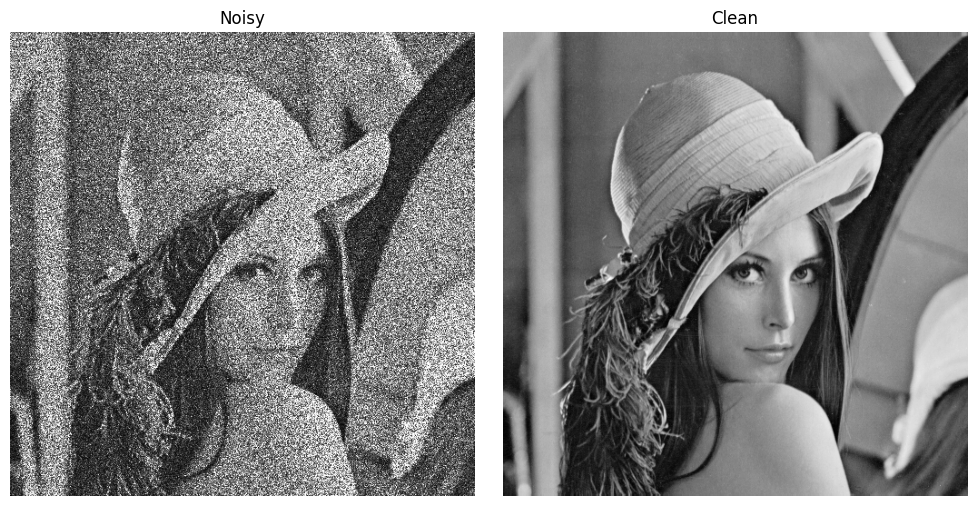

Image shape: (512, 512)
Noisy Image shape: (512, 512)
Image mean: 0.48473498
Noisy Image mean: 0.45580152
Image std: 0.18799537
Noisy Image std: 0.28220677


In [75]:
i = 5
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]

# let's visualise the images with cv2, the images are in numpy array format np.float32 between 0 and 1
plt.figure(figsize=(10,5))
# Noisy
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
# Clean
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", img.shape)
print("Noisy Image shape:", noisy_img.shape)
print("Image mean:", np.mean(img))
print("Noisy Image mean:", np.mean(noisy_img))
print("Image std:", np.std(img))
print("Noisy Image std:", np.std(noisy_img))

Estimated noise variance = 0.058387674


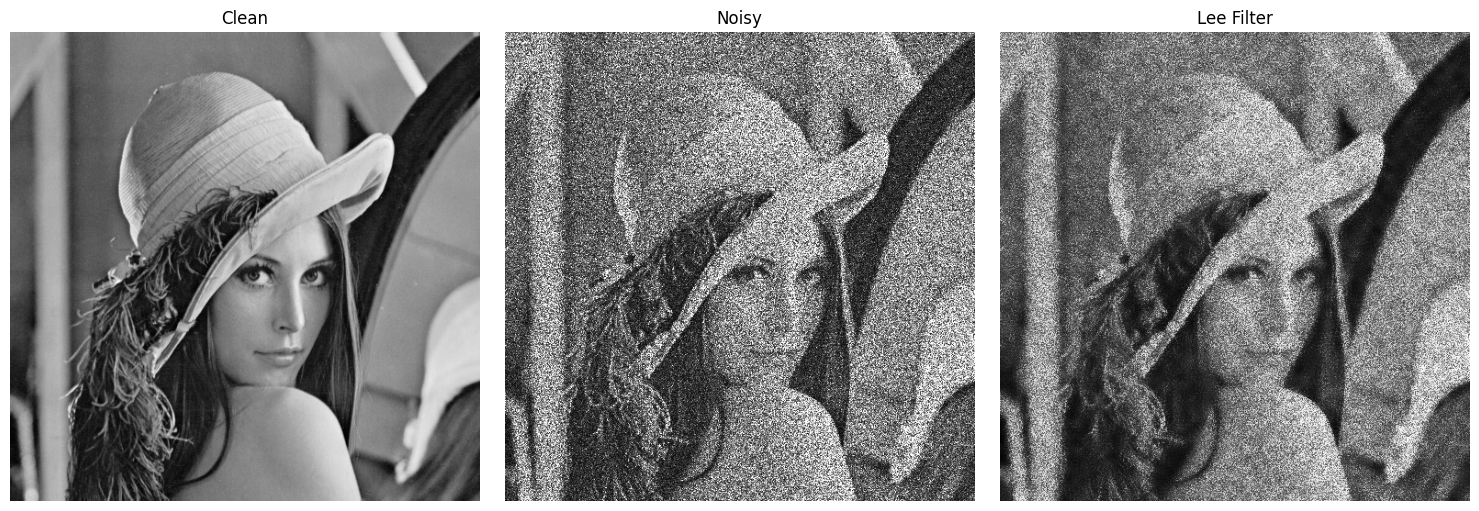

Estimated noise variance = 0.3058834671974182


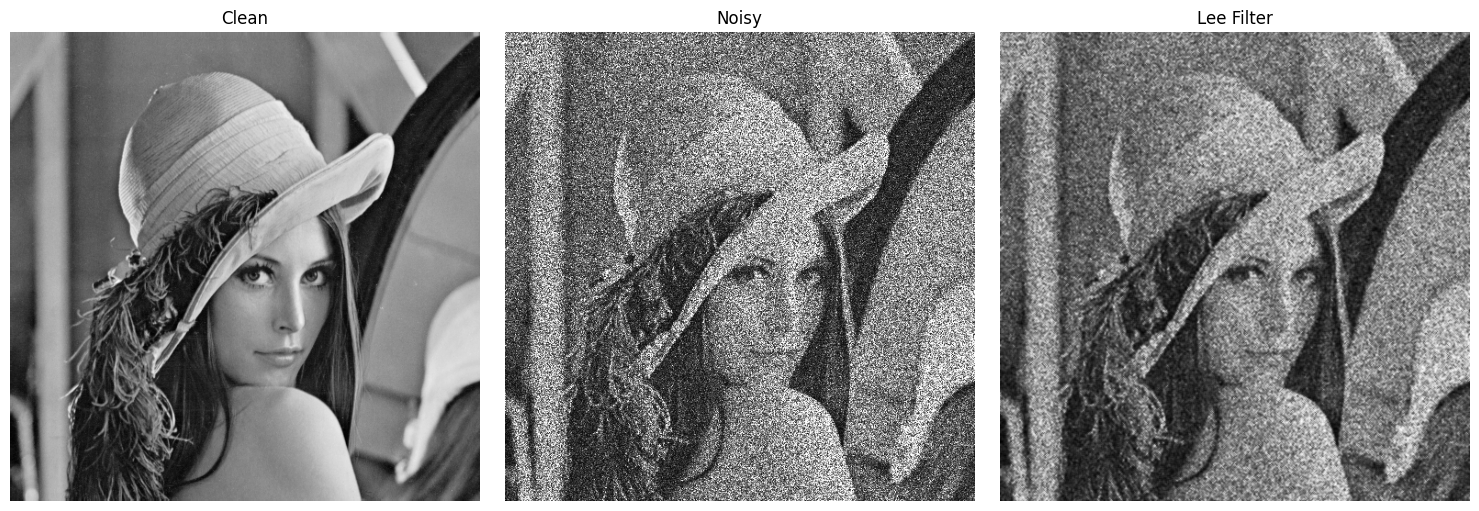

In [79]:
# image float32 [0,1]
lee_img = lee_filter(noisy_img, size=11)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lee_img, cmap='gray')
plt.title("Lee Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

# image float32 [0,1]
lee_img = lee_filter(noisy_img, size=3, noise_var=vN_est)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lee_img, cmap='gray')
plt.title("Lee Filter")
plt.axis("off")

plt.tight_layout()
plt.show()


#### On déduit qu'une meilleure estimation du bruit détériore les performances du filtre de Lee, ce qui suggère que le filtre de Lee a des limites intrinsèques dans sa capacité à réduire le bruit tout en préservant les détails de l'image. C'est contre-intuitif mais c'est ce que les résultats montrent.